In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv('cricket_player_data_fixed.csv')
print(data.head())
print(data.info())

   player_id  age  player_type  experience_years   height_cm  weight_kg  \
0          1   24  All-Rounder                 9  188.629447  91.612592   
1          2   37       Bowler                11  179.691932  70.429037   
2          3   32  All-Rounder                14  178.618982  68.977879   
3          4   28  All-Rounder                 4  187.069279  79.687743   
4          5   25  All-Rounder                13  185.218583  65.016146   

         bmi  body_fat_percent  training_hours_week  bowling_overs_week  ...  \
0  25.747567          9.574633                   20                  22  ...   
1  21.811955         20.722534                   20                  33  ...   
2  21.619947         23.547327                   17                  12  ...   
3  22.771235         15.378357                   17                  42  ...   
4  18.951872         12.398098                   27                  28  ...   

   matches_last_month  days_since_last_match  previous_injuries_coun

In [9]:
# One-hot encode player_type column
data = pd.get_dummies(data, columns=['player_type'], drop_first=True)

# Map injury_risk target variable to numeric labels
injury_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['injury_risk'] = data['injury_risk'].map(injury_mapping)

print(data.head())


   player_id  age  experience_years   height_cm  weight_kg        bmi  \
0          1   24                 9  188.629447  91.612592  25.747567   
1          2   37                11  179.691932  70.429037  21.811955   
2          3   32                14  178.618982  68.977879  21.619947   
3          4   28                 4  187.069279  79.687743  22.771235   
4          5   25                13  185.218583  65.016146  18.951872   

   body_fat_percent  training_hours_week  bowling_overs_week  \
0          9.574633                   20                  22   
1         20.722534                   20                  33   
2         23.547327                   17                  12   
3         15.378357                   17                  42   
4         12.398098                   27                  28   

   batting_hours_week  ...  previous_injuries_count  last_injury_days_ago  \
0                   7  ...                        1                   309   
1                  12 

In [10]:
data = data.drop('player_id', axis=1)  # Drop player_id column as it's an identifier

X = data.drop('injury_risk', axis=1)  # Features
y = data['injury_risk']                # Target


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        40
           1       0.92      0.85      0.88        26
           2       0.91      0.85      0.88        34

    accuracy                           0.87       100
   macro avg       0.88      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



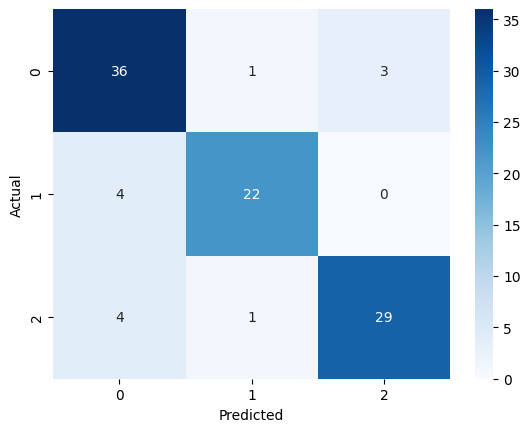

In [13]:
y_pred = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [41]:
import joblib

joblib.dump(rf, 'injury_risk_model.pkl')


['injury_risk_model.pkl']

In [1]:

import joblib

# Load your trained model
model = joblib.load('injury_risk_model.pkl')

# List of feature names your model was trained on (update if different)
feature_names = [
    'age', 'experience_years', 'height_cm', 'weight_kg', 'bmi',
    'body_fat_percent', 'training_hours_week', 'bowling_overs_week',
    'batting_hours_week', 'strength_training_hours', 'matches_last_month',
    'days_since_last_match', 'previous_injuries_count', 'last_injury_days_ago',
    'recovery_days_last_injury', 'fatigue_level', 'sleep_hours_day',
    'stress_level', 'fitness_score', 'player_type_Batsman', 'player_type_Bowler'
]

# Target classes used in training
target_classes = ['Low', 'Medium', 'High']

# Save feature information
feature_info = {
    'feature_names': feature_names,
    'target_classes': target_classes
}

joblib.dump(feature_info, 'model_feature_info.pkl')
print("model_feature_info.pkl has been saved")


model_feature_info.pkl has been saved
